# **Análisis Exploratorio de Datos — Spotify Tracks Dataset**

**MLY1101 — Machine Learning | Evaluación Parcial N°1**

**Caso C**: Inteligencia musical y predicción de popularidad de canciones

Este notebook desarrolla las fases 1 a 3 de CRISP-DM (comprensión del negocio, comprensión de los datos y preparación de los datos) sobre el dataset de canciones de Spotify.

In [1]:
# Verificación de dependencias
import importlib.util
import subprocess
import sys

dependencias = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}

faltantes = [paquete for modulo, paquete in dependencias.items() if importlib.util.find_spec(modulo) is None]

if faltantes:
    print("Instalando dependencias faltantes:", ", ".join(faltantes))
    subprocess.check_call([sys.executable, "-m", "pip", "install", *faltantes])
else:
    print("Dependencias disponibles.")


Dependencias disponibles.


In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Detectar la raíz del proyecto.
# Funciona si el notebook se ejecuta desde repo/ o desde repo/notebooks/.
CURRENT_DIR = Path.cwd().resolve()

ROOT_DIR = None
for candidate in [CURRENT_DIR, *CURRENT_DIR.parents]:
    if (candidate / "notebooks").exists() and (candidate / "data").exists():
        ROOT_DIR = candidate
        break

if ROOT_DIR is None:
    # Caso típico al ejecutar un notebook suelto en Colab.
    ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

DATA_DIR = ROOT_DIR / "data"
IMAGES_DIR = ROOT_DIR / "images"

DATA_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("Raíz del proyecto:", ROOT_DIR)
print("Carpeta de datos:", DATA_DIR)
print("Carpeta de imágenes:", IMAGES_DIR)


Raíz del proyecto: D:\DUOC\Machine_Learning\spotify_track_dataset
Carpeta de datos: D:\DUOC\Machine_Learning\spotify_track_dataset\data
Carpeta de imágenes: D:\DUOC\Machine_Learning\spotify_track_dataset\images


## 1. Carga de datos

Cargamos los datos almacenados en github al entorno de colab.

In [3]:
# Ruta y descarga reproducible del dataset
from urllib.request import urlretrieve

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "monkIIlol/spotify_track_dataset/main/data/Spotify_Tracks_Dataset.csv"
)

DATA_PATH = DATA_DIR / "Spotify_Tracks_Dataset.csv"

if DATA_PATH.exists():
    print("Dataset encontrado en:", DATA_PATH)
else:
    print("Dataset no encontrado localmente. Descargando desde GitHub...")
    urlretrieve(DATA_URL, DATA_PATH)
    print("Dataset descargado en:", DATA_PATH)


Dataset encontrado en: D:\DUOC\Machine_Learning\spotify_track_dataset\data\Spotify_Tracks_Dataset.csv


A los datos cargados, le asignamos la variable **`BD`** e imprimimos las 3 primeras filas para una primera impresión a los datos.

In [4]:
BD = pd.read_csv(DATA_PATH)
BD.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


In [5]:
print(BD.shape)

(114000, 21)


El dataset cuenta con 114000 registros y 21 variables.

## 2. Comprensión de los datos Primer perfil general: dimensiones y tipos de cada columna.

In [6]:
print(BD.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

Se aprecian solamente 3 nulos en `artists`, `album_name` y `track_name` (1 por cada columna), posiblemente pertenezcan al mismo registro.

Esto queda pendiente para los apartados posteriores dirigidos a el diagnostico de calidad de los datos.

---
### Descripción de las columnas

#### 1. Identificación de la canción

* **`track_id`**
  Identificador único de la canción en Spotify.

* **`track_name`**
  Nombre de la canción.

* **`artists`**
  Artistas que interpretan la canción. Cuando participa más de uno, sus nombres aparecen separados por `;`.

* **`album_name`**
  Álbum en el que aparece la canción.

* **`track_genre`**
  Género asignado a la canción.

---

#### 2. Información general

* **`popularity`**
  Popularidad de la canción en una escala de **0 a 100**, donde 100 representa la mayor popularidad.

  El valor depende principalmente de:

  * La cantidad total de reproducciones.
  * Qué tan recientes son esas reproducciones.

  Una misma canción puede recibir puntuaciones diferentes si aparece, por ejemplo, como sencillo y como parte de un álbum.

* **`duration_ms`**
  Duración de la canción expresada en milisegundos.

* **`explicit`**
  Indica si la canción contiene letras explícitas:

  * `true`: contiene letras explícitas.
  * `false`: no contiene letras explícitas o se desconoce.

---

#### 3. Características perceptuales del audio

Estas variables se expresan principalmente en una escala de **0,0 a 1,0**.

* **`danceability`**
  Indica qué tan adecuada es la canción para bailar. Considera elementos como el tempo, la estabilidad del ritmo, la fuerza del pulso y la regularidad general.

  * `0,0`: poco bailable.
  * `1,0`: muy bailable.

* **`energy`**
  Representa la intensidad y actividad percibidas. Las canciones rápidas, fuertes o ruidosas suelen presentar valores más altos.

  * `0,0`: baja energía.
  * `1,0`: alta energía.

* **`speechiness`**
  Detecta la presencia de palabras habladas.

  * Menor que `0,33`: principalmente música.
  * Entre `0,33` y `0,66`: combinación de música y habla.
  * Mayor que `0,66`: predominio de contenido hablado.

* **`acousticness`**
  Nivel de confianza de que la canción sea acústica.

  * `0,0`: baja confianza.
  * `1,0`: alta confianza.

* **`instrumentalness`**
  Estima la probabilidad de que la canción no contenga voces. Los sonidos como «ooh» y «aah» se consideran instrumentales, mientras que el rap y las palabras habladas se consideran vocales.

  Los valores cercanos a `1,0` indican una mayor probabilidad de que sea instrumental.

* **`liveness`**
  Estima la presencia de público en la grabación. Los valores superiores a `0,8` indican una alta probabilidad de que haya sido grabada en vivo.

* **`valence`**
  Describe la positividad musical transmitida por la canción.

  * Valores altos: sonido alegre, animado o eufórico.
  * Valores bajos: sonido triste, deprimido o enojado.

* **`loudness`**
  Volumen sonoro general de la canción, medido en decibelios (`dB`).

---

#### 4. Características musicales

* **`key`**
  Tonalidad principal de la canción. Los números representan notas musicales:

  * `0`: Do
  * `1`: Do♯/Re♭
  * `2`: Re
  * Continúa sucesivamente hasta `11`.
  * `-1`: no se detectó una tonalidad.

* **`mode`**
  Indica el modo musical:

  * `1`: modo mayor.
  * `0`: modo menor.

* **`tempo`**
  Velocidad estimada de la canción, medida en pulsaciones por minuto (`BPM`).

* **`time_signature`**
  Compás estimado de la canción. Indica cuántos pulsos contiene cada compás o medida. Sus valores van desde `3` hasta `7`, correspondientes a compases como `3/4` y `7/4`.

---


## 3. Diagnóstico de calidad de datos

### 3.1 Valores faltantes
Retomamos lo que quedó pendiente en la sección 2

In [7]:
print("Valores nulos por columna:")
print(BD.isnull().sum()[BD.isnull().sum() > 0])

Valores nulos por columna:
artists       1
album_name    1
track_name    1
dtype: int64


Confirmamos que hay 3 nulos en `artists`, `album_name` y `track_name` (1 por cada columna), queda pendiente descubrir que ocurrió con ese registro.

### 3.2 Registros duplicados

Primero vemos si hay duplicación de registros exactos

In [8]:
duplicated_rows = BD.duplicated().sum()

if duplicated_rows == 0:
    print('Hay 0 filas repetidas, lo que significa que cada fila en el DataFrame es unica.')
else:
    print(f'Hay {duplicated_rows} filas que estan duplicadas a si que necesitamos eliminar {duplicated_rows} filas')
    BD = BD.drop_duplicates()
    print(f'After drop duplicated rows, there are {BD.shape[0]} rows left')
    print(f'Despues de eliminar las filas duplicadas, hay {BD.shape[0]} filas en total')

Hay 0 filas repetidas, lo que significa que cada fila en el DataFrame es unica.


No hay registros exactamente duplicados.

 `track_id` se repite miles de veces en el dataset. Antes de eliminar nada hay que entender **por qué**.

In [9]:
print("Filas con track_id repetido:", BD['track_id'].duplicated().sum())
print()
ejemplo_id = BD['track_id'].value_counts().index[0]
print("Ejemplo de una cancion repetida en varios generos:")
print(BD[BD['track_id'] == ejemplo_id][['track_name','artists','track_genre']])

Filas con track_id repetido: 24259

Ejemplo de una cancion repetida en varios generos:
                         track_name    artists        track_genre
8315    Baby Blue - Remastered 2010  Badfinger              blues
19759   Baby Blue - Remastered 2010  Badfinger            country
34728   Baby Blue - Remastered 2010  Badfinger               folk
62226   Baby Blue - Remastered 2010  Badfinger              j-pop
63087   Baby Blue - Remastered 2010  Badfinger             j-rock
82064   Baby Blue - Remastered 2010  Badfinger          power-pop
84129   Baby Blue - Remastered 2010  Badfinger         psych-rock
99727   Baby Blue - Remastered 2010  Badfinger  singer-songwriter
102732  Baby Blue - Remastered 2010  Badfinger         songwriter


**Hallazgo:** no es un error de captura. La misma canción está etiquetada en varios géneros musicales a la vez (en el ejemplo de arriba, el mismo tema aparece repetido bajo distintos `track_genre`). Por lo tanto, **no corresponde aplicar `.drop_duplicates()` sobre el DataFrame completo**, porque se perdería información real de multi-género.

Se deja documentado como una particularidad del dataset, no como suciedad de los datos.

### 3.3 Outliers evidentes: duración de la canción

In [10]:
print("Canciones con duración cero =", (BD['duration_ms'] == 0).sum())
print(BD[BD['duration_ms'] == 0][['track_name','artists','track_genre','duration_ms']])

Canciones con duración cero = 1
      track_name artists track_genre  duration_ms
65900        NaN     NaN       k-pop            0


**Hallazgo:** En el punto 3.1 vimos los valores nulos del dataset y ahora descubrimos que es solo una fila la que tiene los valores nulos de `artists`, `album_name` y `track_name` — un único registro completamente corrupto en el origen de los datos.

## 4. Ingeniería de Datos

Agregaremos características simples para mejorar interpretabilidad y análisis:

- duration_m → duration_min: convertido a minutos
- mode → mode_name: map mode (0/1) → Minor/Major
- key → key_map: map key (0,1,2,...10,11) → C, C#/Db, D, ..., A#/Bb, B

In [11]:
# duration_m → duration_min
BD["duration_min"] = BD["duration_ms"] / 60000

# mode → mode_name
BD["mode_name"] = BD["mode"].map({1: "Major", 0: "Minor"})

# key → key_map
key_map = {
    0: "C", 1: "C#/Db", 2: "D", 3: "D#/Eb",
    4: "E", 5: "F", 6: "F#/Gb", 7: "G",
    8: "G#/Ab", 9: "A", 10: "A#/Bb", 11: "B",
    -1: "Unknown"
}
BD["key_name"] = BD["key"].map(key_map)

# Ver resultados
print(BD[
    [
        "duration_ms", "duration_min",
        "mode", "mode_name",
        "key", "key_name"
    ]
].head(3))

   duration_ms  duration_min  mode mode_name  key key_name
0       230666      3.844433     0     Minor    1    C#/Db
1       149610      2.493500     1     Major    1    C#/Db
2       210826      3.513767     1     Major    0        C


## 5. Limpieza

Borramos las columnas que fueron reemplazadas en la etapa de ingeniería de características (`duration_ms`, `mode` y `key`).

Borramos la columna indexadora `Unnamed: 0` ya que no cumple con características predictivas.

In [12]:
columnas_eliminar = [
    "Unnamed: 0",
    "duration_ms",
    "mode",
    "key"
]

BD_limpia = BD.drop(columns=columnas_eliminar)

BD_limpia.head(3)

,track_id,artists,album_name,track_name,popularity,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min,mode_name,key_name
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,False,0.676,0.461,-6.746,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic,3.844433,Minor,C#/Db
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,False,0.420,0.166,-17.235,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic,2.493500,Major,C#/Db
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,False,0.438,0.359,-9.734,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic,3.513767,Major,C


Borramos el registro que contenía el duplicado

In [13]:
BD_limpia = BD_limpia.dropna(subset=['artists', 'album_name', 'track_name'])
print(f"Filas antes: 114000 -> despues de eliminar el registro corrupto: {BD_limpia.shape[0]}")
print(f"Columnas antes: 21 -> despues de la etapa de feature engineering: {BD_limpia.shape[1]}")
print(f"duración cero despues de la limpieza: {(BD_limpia['duration_min'] == 0).sum()}")

Filas antes: 114000 -> despues de eliminar el registro corrupto: 113999
Columnas antes: 21 -> despues de la etapa de feature engineering: 20
duración cero despues de la limpieza: 0


## 6. Análisis univariado: distribución de la variable objetivo (`popularity`)

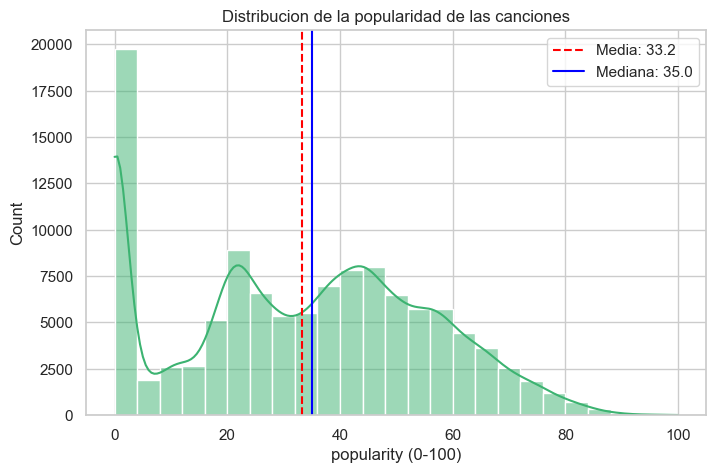

Media: 33.24
Mediana: 35.00
Sesgo (skew): 0.05


In [14]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(data=BD_limpia, x='popularity', kde=True, color='mediumseagreen', bins=25)
plt.axvline(BD_limpia['popularity'].mean(), color='red', linestyle='--', label=f"Media: {BD_limpia['popularity'].mean():.1f}")
plt.axvline(BD_limpia['popularity'].median(), color='blue', linestyle='-', label=f"Mediana: {BD_limpia['popularity'].median():.1f}")
plt.title('Distribucion de la popularidad de las canciones')
plt.xlabel('popularity (0-100)')
plt.legend()
plt.savefig(IMAGES_DIR / "01_distribucion_popularity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Media: {BD_limpia['popularity'].mean():.2f}")
print(f"Mediana: {BD_limpia['popularity'].median():.2f}")
print(f"Sesgo (skew): {BD_limpia['popularity'].skew():.2f}")

**Hallazgo:** el sesgo (skew) es prácticamente 0, lo que indica una distribución bastante simétrica (a diferencia de lo que suele pasar con variables de ingreso o edad). La media y la mediana están muy cerca (33.2 y 35.0).

La distribución general no presenta una asimetría fuerte, pero existe una concentración anómala en popularity = 0 que representa aproximadamente el 14% del dataset y debe considerarse en futuras decisiones de modelamiento.

### 6.1 Anomalía a evaluar: popularity = 0

In [15]:
canciones_popularity_cero = BD[BD['popularity'] == 0]
print(f"Canciones con popularity = 0: {canciones_popularity_cero.shape[0]} ({canciones_popularity_cero.shape[0]/BD.shape[0]*100:.1f}% del total)")

Canciones con popularity = 0: 16020 (14.1% del total)


**A decidir en equipo:** el 14% de las canciones con `popularity = 0` puede corresponder a canciones genuinamente poco escuchadas (dato real, no error) o a un artefacto de la fecha en que se capturó el dataset desde la API de Spotify. No se elimina sin más — es una decisión de negocio, no solo estadística (no todo valor atípico es un error).

### 6.2 Relación entre `popularity = 0` y canciones repetidas

Se observó una concentración importante de canciones con `popularity = 0`.

Para investigar si estos valores se distribuyen de manera similar en todo el dataset, se comparan las canciones cuyo `track_id` aparece más de una vez con aquellas que aparecen una sola vez.

In [16]:
# Identificar canciones cuyo track_id aparece más de una vez
track_repetido = BD_limpia['track_id'].duplicated(keep=False)

# Porcentaje de popularity = 0 en cada grupo
pct_cero_repetidos = (
    BD_limpia.loc[track_repetido, 'popularity']
    .eq(0)
    .mean() * 100
)

pct_cero_unicos = (
    BD_limpia.loc[~track_repetido, 'popularity']
    .eq(0)
    .mean() * 100
)

print(f"Popularity = 0 en canciones con track_id repetido: {pct_cero_repetidos:.1f}%")
print(f"Popularity = 0 en canciones con track_id único: {pct_cero_unicos:.1f}%")

Popularity = 0 en canciones con track_id repetido: 25.3%
Popularity = 0 en canciones con track_id único: 7.7%


**Hallazgo:** `popularity = 0` aparece con mucha mayor frecuencia entre canciones cuyo `track_id` está repetido en el dataset (aprox. 25%) que entre canciones que aparecen una sola vez (aprox. 7%).

Esto muestra una asociación entre la repetición de una canción dentro del dataset y la presencia de valores de popularidad iguales a cero. Sin embargo, esta relación por sí sola no permite afirmar que dichos valores sean errores o ruido de captura.

Por esta razón, los registros con `popularity = 0` se conservan, pero su interpretación debe realizarse con cautela.

## 7. duración de las canciones (regla IQR)

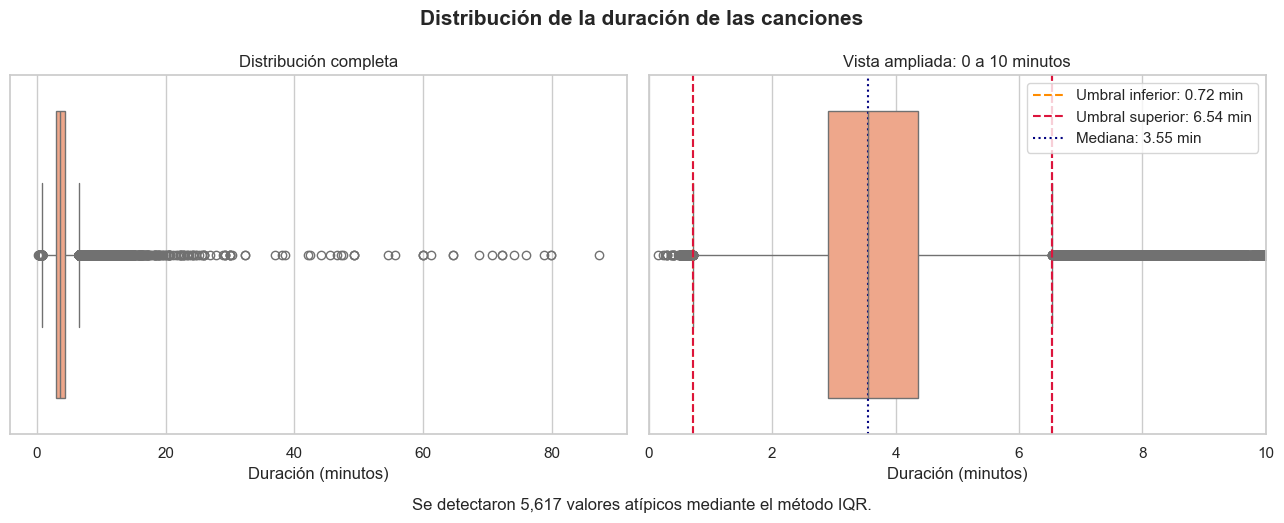

In [17]:
duration_min = BD_limpia["duration_min"]

Q1 = duration_min.quantile(0.25)
mediana = duration_min.median()
Q3 = duration_min.quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = duration_min[
    (duration_min < limite_inferior) |
    (duration_min > limite_superior)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x=duration_min, ax=axes[0], color="lightsalmon")
axes[0].set_title("Distribución completa")
axes[0].set_xlabel("Duración (minutos)")

sns.boxplot(x=duration_min, ax=axes[1], color="lightsalmon")
axes[1].set_xlim(0, 10)
axes[1].set_title("Vista ampliada: 0 a 10 minutos")
axes[1].set_xlabel("Duración (minutos)")

## Umbral inferior
axes[1].axvline(
    limite_inferior,
    color="darkorange",
    linestyle="--",
    linewidth=1.5,
    label=f"Umbral inferior: {limite_inferior:.2f} min"
)

# Umbral superior
axes[1].axvline(
    limite_superior,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f"Umbral superior: {limite_superior:.2f} min"
)

# Mediana
axes[1].axvline(
    mediana,
    color="navy",
    linestyle=":",
    linewidth=1.5,
    label=f"Mediana: {mediana:.2f} min"
)

axes[1].legend(loc="upper right")

axes[1].legend()

fig.suptitle(
    "Distribución de la duración de las canciones",
    fontsize=15,
    fontweight="bold"
)

axes[1].axvline(
    limite_inferior,
    color="crimson",
    linestyle="--",
    label=f"Umbral inferior: {limite_inferior:.2f} min"
)

axes[1].axvline(
    limite_superior,
    color="crimson",
    linestyle="--",
    label=f"Umbral superior: {limite_superior:.2f} min"
)

fig.text(
    0.5, -0.02,
    f"Se detectaron {len(outliers):,} valores atípicos mediante el método IQR.",
    ha="center"
)

plt.tight_layout()
fig.savefig(IMAGES_DIR / "02_outliers_duracion_iqr.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
outliers_inferiores = BD_limpia[duration_min < limite_inferior]
outliers_superiores = BD_limpia[duration_min > limite_superior]
total_outliers = len(outliers_inferiores) + len(outliers_superiores)
print(f'Atipicos inferiores: {len(outliers_inferiores)} \nAtipicos superiores: {len(outliers_superiores)} \nTotal atipicos: {total_outliers}')

display(
    outliers_inferiores[
        ["track_name", "artists", "track_genre", "duration_min"]
    ].sort_values("duration_min").head(5)
)

display(
    outliers_superiores[
        ["track_name", "artists", "track_genre", "duration_min"]
    ].sort_values("duration_min", ascending=False).head(5)
)

Atipicos inferiores: 273 
Atipicos superiores: 5344 
Total atipicos: 5617


,track_name,artists,track_genre,duration_min
59310,The Exorsism Begins...,Leila Bela,iranian,0.143100
59812,V-4,Leila Bela,iranian,0.223100
59775,Screams for a Finale! (feat. Leila's Opera Class),Leila Bela;Leila's Opera Class,iranian,0.263333
16856,"Andante in C Major, K. 1a",Wolfgang Amadeus Mozart;Ingrid Haebler,classical,0.290883
39233,"Carnaval, Op. 9: No. 20, Pause (Live in Japan,...",Robert Schumann;Pavel Nersessian,german,0.297100


,track_name,artists,track_genre,duration_min
73617,Unity (Voyage Mix) Pt. 1,Tale Of Us,minimal-techno,87.288250
10984,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,breakbeat,79.817100
10935,Crossing Wires 002 - Continuous DJ Mix,Timo Maas,breakbeat,79.817100
24348,The Lab 03 - Continuous DJ Mix Part 1,Seth Troxler,detroit-techno,78.838367
73840,Amnesia Ibiza Underground 10 DJ Mix,Loco Dice,minimal-techno,76.064950


**Hallazgo:** 5.617 canciones quedan fuera del rango típico de duración (0.72 a 6.54 minutos). Esto incluye tanto interludios/intros muy cortas como temas extendidos (ej. mezclas extendidas, tracks de jazz o clásica). No son necesariamente errores, requieren revisión por género antes de decidir si se filtran.

## 8. Análisis bivariado y Evaluación ética

### 8.1 correlación entre variables de audio y popularidad

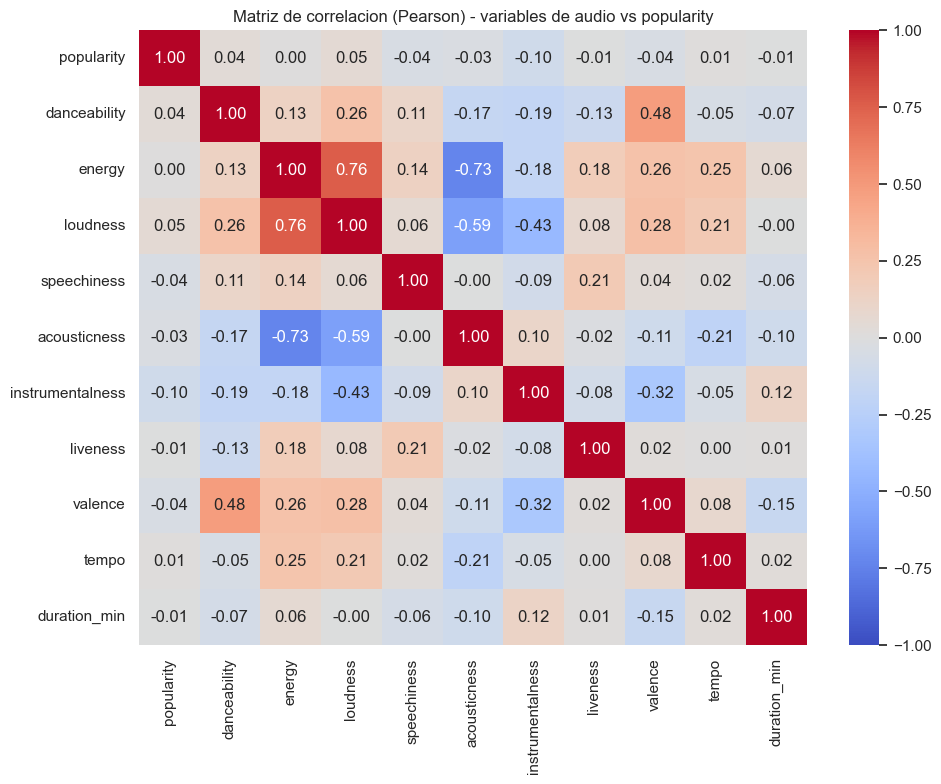

Correlacion de cada variable con 'popularity':
popularity          1.000000
loudness            0.050420
danceability        0.035444
tempo               0.013212
energy              0.001053
liveness           -0.005397
duration_min       -0.007129
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64


In [19]:
columnas_numericas = ['popularity','danceability','energy','loudness','speechiness','acousticness','instrumentalness','liveness','valence','tempo','duration_min']
matriz_corr = BD_limpia[columnas_numericas].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de correlacion (Pearson) - variables de audio vs popularity')
plt.tight_layout()
plt.savefig(IMAGES_DIR / "03_matriz_correlacion_pearson.png", dpi=300, bbox_inches="tight")
plt.show()
print("Correlacion de cada variable con 'popularity':")
print(matriz_corr['popularity'].sort_values(ascending=False))

**Hallazgo clave del proyecto:** ninguna variable de audio muestra una correlación relevante con `popularity` (la más fuerte, `instrumentalness`, es solo -0.095). Esto tiene una lectura de negocio directa: **la popularidad de una canción no se explica principalmente por cómo suena**, sino probablemente por factores externos al audio (fama del artista, presencia en playlists editoriales, marketing). Es un hallazgo válido para el informe, no un fracaso del análisis — condiciona qué se puede esperar de un futuro modelo predictivo basado solo en estas variables.

Algunas características de audio contienen información parcialmente redundante, especialmente `energy`, `loudness` y `acousticness`. Esto deberá considerarse durante la selección de variables y elección del modelo.

### 8.2 Comparación de la popularidad promedio entre géneros musicales + Evaluación Ética.

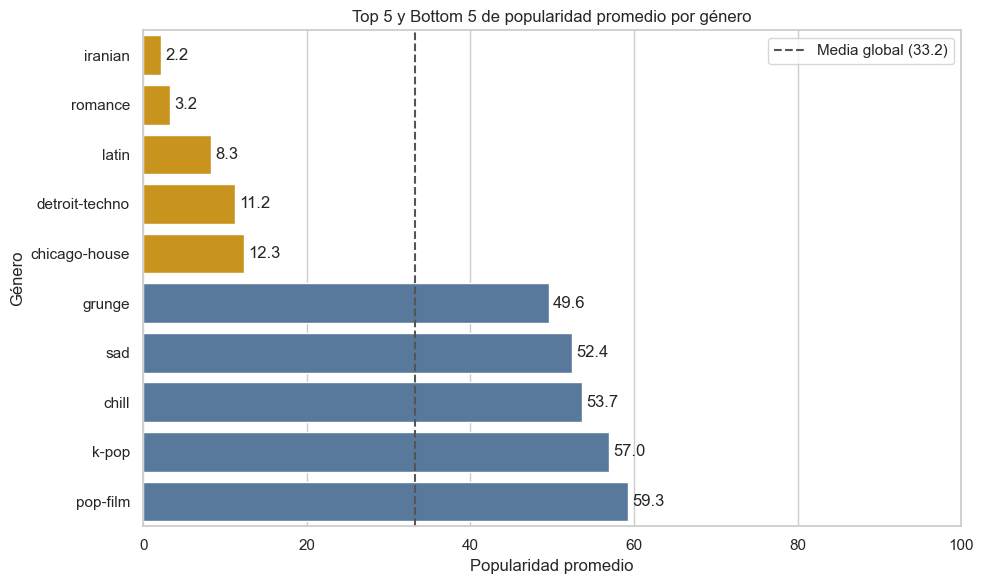

In [20]:
popularidad_genero = (
    BD_limpia.groupby('track_genre')['popularity']
    .mean()
    .sort_values()
)

# Seleccionar 5 géneros con menor y 5 con mayor popularidad promedio
comparacion_generos = pd.concat([
    popularidad_genero.head(5),
    popularidad_genero.tail(5)
])

# Media global de popularidad
media_global = BD_limpia['popularity'].mean()

colores = (
    ['#E69F00'] * 5 +
    ['#4C78A8'] * 5
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=comparacion_generos.values,
    y=comparacion_generos.index,
    palette=colores,
    hue=comparacion_generos.index,
    legend=False
)

# Línea de referencia con la media global
plt.axvline(
    media_global,
    color='#555555',
    linestyle='--',
    linewidth=1.5,
    label=f'Media global ({media_global:.1f})'
)

# Títulos y ejes
plt.title('Top 5 y Bottom 5 de popularidad promedio por género')
plt.xlabel('Popularidad promedio')
plt.ylabel('Género')

# popularity va de 0 a 100
plt.xlim(0, 100)

# Mostrar valores al final de las barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f',
        padding=3
    )

plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "04_popularidad_promedio_genero.png", dpi=300, bbox_inches="tight")
plt.show()

**Hallazgo y reflexión ética:** géneros como `k-pop` (56.9) tienen popularidad promedio muy superior a géneros como `iranian`, `romance` o `latin` (todos por debajo de 10). Esta diferencia probablemente **no refleja menor calidad musical**, sino menor penetración histórica de Spotify en esos mercados y catálogos/playlists editoriales más reducidos en esos idiomas, un caso de **sesgo histórico/de selección** heredado de cómo la propia plataforma recolectó y expuso los datos. **Recomendación:** un modelo entrenado sobre `popularity` no debería usarse para inferir "valor cultural" o calidad de un género musical, solo para estimar comportamiento de consumo dentro de la plataforma Spotify. Esta limitación debe quedar explícita en cualquier producto o reporte derivado de este análisis.

## 8.3 Popularidad segun contenido explícito

C:\Users\emili\AppData\Local\Temp\ipykernel_23176\2963044152.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


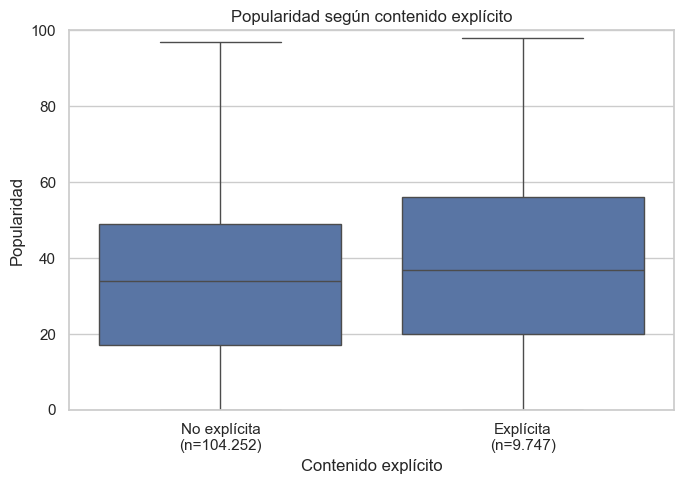

In [21]:
plt.figure(figsize=(7, 5))

ax = sns.boxplot(
    data=BD_limpia,
    x="explicit",
    y="popularity",
    showfliers=False
)

conteos = BD_limpia["explicit"].value_counts()

ax.set_xticklabels([
    f"No explícita\n(n={conteos[False]:,})".replace(",", "."),
    f"Explícita\n(n={conteos[True]:,})".replace(",", ".")
])

plt.title("Popularidad según contenido explícito")
plt.xlabel("Contenido explícito")
plt.ylabel("Popularidad")
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "05_popularidad_contenido_explicito.png", dpi=300, bbox_inches="tight")
plt.show()

**Hallazgo**: las canciones explícitas presentan una popularidad ligeramente superior, aunque existe una amplia superposición entre ambos grupos. Esto sugiere que el contenido explícito está asociado con diferencias pequeñas de popularidad, pero no constituye por sí solo un factor diferenciador fuerte.

### 8.4 Variabilidad de popularidad dentro de un mismo artista

¿Las canciones de un mismo artista tienen popularidad parecida, o hay mucha dispersión? Se agrupa por artista, filtrando solo quienes tienen 10 o más canciones para evitar conclusiones con muestras chicas.

In [22]:
popularidad_artista = BD_limpia.groupby('artists')['popularity'].agg(
    cantidad='count',
    promedio='mean',
    desviacion='std',
    minimo='min',
    maximo='max'
)

popularidad_artista = popularidad_artista[
    popularidad_artista['cantidad'] >= 10
].sort_values('desviacion', ascending=False)

popularidad_artista.head(10)

,cantidad,promedio,desviacion,minimo,maximo
artists,,,,,
Taylor Swift,11,46.363636,42.842205,0,88
The Weeknd,15,31.200000,42.347542,0,91
Bruno Mars,12,35.666667,42.000721,0,87
Doja Cat,12,56.250000,41.672151,0,90
Shawn Mendes,21,39.047619,41.301908,0,86
Ed Sheeran,13,27.384615,41.051875,0,88
Sia,12,47.000000,40.460980,0,82
Marshmello;Jonas Brothers,16,29.687500,40.433845,0,85
Kate Bush,37,38.054054,40.032588,0,90


**Hallazgo:** los artistas con mayor dispersión no son artistas "irregulares", son superestrellas (Taylor Swift, The Weeknd, Bruno Mars) que combinan canciones con popularidad muy alta y otras en 0. Revisando el detalle, varias de esas canciones en 0 son versiones duplicadas del mismo tema (ej. "Lover" aparece dos veces, una en 0).

La presencia de popularity = 0 está fuertemente asociada con canciones repetidas o reeditadas, por lo que estos valores requieren cautela antes de interpretarse directamente como ausencia de popularidad.

## 9. Próximos pasos (fuera del alcance de esta entrega)
- Codificar `track_genre` (variable categórica) para uso en modelos.- Evaluar variables adicionales no incluidas en este dataset (fecha de lanzamiento, seguidores del artista, presencia en playlists) dado que las variables de audio explican muy poco de `popularity`.- Decidir tratamiento final de las canciones con `popularity = 0`.- Entrenamiento y evaluación del modelo → Evaluación 2.

## Archivos de salida

Al ejecutar el notebook, los gráficos se guardan automáticamente en la carpeta `images/` en formato PNG y con resolución de 300 dpi.

Archivos generados:

- `01_distribucion_popularity.png`
- `02_outliers_duracion_iqr.png`
- `03_matriz_correlacion_pearson.png`
- `04_popularidad_promedio_genero.png`
- `05_popularidad_contenido_explicito.png`
